In [2]:
import pandas as pd

data = pd.read_csv("eeg_epilepsy_dataset.csv")

print("Shape:", data.shape)
print("Columns:", data.columns)
print(data.head())
print(data['label'].value_counts())   # check class distribution


Shape: (150, 1025)
Columns: Index(['sample_0', 'sample_1', 'sample_2', 'sample_3', 'sample_4', 'sample_5',
       'sample_6', 'sample_7', 'sample_8', 'sample_9',
       ...
       'sample_1015', 'sample_1016', 'sample_1017', 'sample_1018',
       'sample_1019', 'sample_1020', 'sample_1021', 'sample_1022',
       'sample_1023', 'label'],
      dtype='object', length=1025)
   sample_0  sample_1  sample_2  sample_3  sample_4  sample_5  sample_6  \
0         9         1        -1        -1        -1         0         1   
1       -10        -8        -7        -5        -3        -2        -2   
2        48        51        50        45        33        24        22   
3       -14        -4         4        12        16        16        16   
4        84        92       104       112       115       113       108   

   sample_7  sample_8  sample_9  ...  sample_1015  sample_1016  sample_1017  \
0        -1        -5        -4  ...          218          216          221   
1        -3      

In [3]:
print(data.isnull().sum())
data = data.dropna()   # or fillna() if needed


sample_0       0
sample_1       0
sample_2       0
sample_3       0
sample_4       0
              ..
sample_1020    0
sample_1021    0
sample_1022    0
sample_1023    0
label          0
Length: 1025, dtype: int64


In [4]:
X = data.drop("label", axis=1).values
y = data["label"].values


In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
features = data.drop(columns=['label'])
scaled_features = scaler.fit_transform(features)
X = scaled_features
y = data['label'].values


#DISPLAY THE TRANSFORMED FEATURES
print(X[:5])

[[0.43310345 0.46764706 0.52998379 ... 0.80994152 0.74555404 0.71787709]
 [0.40689655 0.45441176 0.52025932 ... 0.40935673 0.36662107 0.33240223]
 [0.48689655 0.54117647 0.61264182 ... 0.22660819 0.22298222 0.21089385]
 [0.40137931 0.46029412 0.53808752 ... 0.46783626 0.42954856 0.39804469]
 [0.53655172 0.60147059 0.70016207 ... 0.49415205 0.4623803  0.43575419]]


In [5]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

encoder = LabelEncoder()
y = encoder.fit_transform(y)
y = to_categorical(y)



In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Load dataset
data = pd.read_csv("eeg_epilepsy_dataset.csv")

# Separate features and labels
X = data.drop("label", axis=1).values
y = data["label"].values

# Choose normalization method
# 1. Min-Max
mm_scaler = MinMaxScaler(feature_range=(0,1))
X_minmax = mm_scaler.fit_transform(X)

# 2. Standardization (Z-score)
std_scaler = StandardScaler()
X_standardized = std_scaler.fit_transform(X)

# 3. Robust scaling
rob_scaler = RobustScaler()
X_robust = rob_scaler.fit_transform(X)

# Print details
print("Original Mean:", np.mean(X, axis=0)[:5])
print("Standardized Mean:", np.mean(X_standardized, axis=0)[:5])
print("Standardized Std:", np.std(X_standardized, axis=0)[:5])
print("MinMax Range:", X_minmax.min(), "to", X_minmax.max())


Original Mean: [-3.32666667 -1.98       -0.53333333  0.09333333  0.49333333]
Standardized Mean: [-5.92118946e-18  0.00000000e+00  5.92118946e-18 -1.18423789e-17
 -1.18423789e-17]
Standardized Std: [1. 1. 1. 1. 1.]
MinMax Range: 0.0 to 1.0000000000000002


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)


In [7]:
X = X.reshape((X.shape[0], X.shape[1], 1))


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

# First LSTM layer
model.add(LSTM(64, input_shape=(X.shape[1], 1), return_sequences=True))
model.add(Dropout(0.3))

# Second LSTM layer
model.add(LSTM(32))
model.add(Dropout(0.3))

# Fully connected output
model.add(Dense(y.shape[1], activation="softmax"))


c:\Users\rajas\anaconda3\envs\end310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.compile(
    loss="categorical_crossentropy",   # binary_crossentropy if 2 classes
    optimizer="adam",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1024, 64)       │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,411 (114.89 KB)

 Trainable params: 29,411 (114.89 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30, batch_size=32, verbose=1
)


Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 596ms/step - accuracy: 0.2606 - loss: 1.1026 - val_accuracy: 0.5667 - val_loss: 1.0774
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 445ms/step - accuracy: 0.4615 - loss: 1.0691 - val_accuracy: 0.6333 - val_loss: 1.0510
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - accuracy: 0.4694 - loss: 1.0473 - val_accuracy: 0.6000 - val_loss: 1.0205
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 440ms/step - accuracy: 0.4467 - loss: 1.0062 - val_accuracy: 0.6000 - val_loss: 0.9782
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 433ms/step - accuracy: 0.5404 - loss: 0.9539 - val_accuracy: 0.6000 - val_loss: 0.9289
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - accuracy: 0.6183 - loss: 0.9197 - val_accuracy: 0.4000 - val_loss: 0.8796
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 486ms/step - accuracy: 0.5548 - loss: 0.8130 - val_accuracy: 0.6000 - val_loss: 0.8144
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 466ms/step - accuracy: 0.6069 - loss: 0.7940 - val_accuracy: 0.5667 - val_loss:

In [14]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.2f}")


Test Accuracy: 0.73


In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(confusion_matrix(y_true, y_pred_classes))
print(classification_report(y_true, y_pred_classes))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
[[10  0  0]
 [ 1  9  0]
 [ 1  6  3]]
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       0.60      0.90      0.72        10
           2       1.00      0.30      0.46        10

    accuracy                           0.73        30
   macro avg       0.81      0.73      0.70        30
weighted avg       0.81      0.73      0.70        30



In [16]:
sample = X_test[0].reshape(1, X_test.shape[1], 1)
prediction = model.predict(sample)
print("Predicted class:", encoder.inverse_transform([np.argmax(prediction)]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
Predicted class: ['interictal']


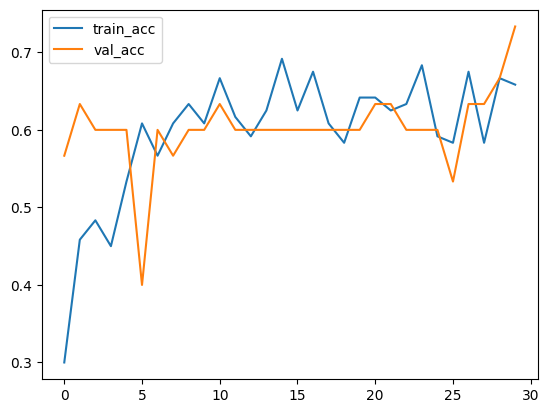

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()
